In [9]:
import os
import sys
import pandas as pd
sys.path.append(os.path.abspath("utils"))

import importlib
import quant_concept_evals_utils
importlib.reload(quant_concept_evals_utils)

from quant_concept_evals_utils import evaluate_baseline_models_across_dataset, compute_concept_metrics

/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# Run Baselines

In [120]:
for dataset_name in ['CLEVR', 'Coco']:
    for model_name, model_input_size in [('CLIP', (224, 224)), ('Llama', (560, 560))]:
        
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_inputsize_{model_input_size}.pt')
        gt_patches_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_patches_per_concept_inputsize_{model_input_size}.pt')
        
        per_image_baselines = evaluate_baseline_models_across_dataset(gt_samples_per_concept, dataset_name, 'image', model_input_size, 
                                                     patch_size=14, all_object_patches=None, balance_dataset=False, 
                                                     n_trials=1)
        
        con_label = f"{model_name}_cls_baseline"
        for baseline_type, (fp, fn, tp, tn) in per_image_baselines.items():
            compute_concept_metrics(fp, fn, tp, tn, gt_samples_per_concept.keys(), 
                                    dataset_name, con_label, just_obj=False, baseline_type=baseline_type)
        
        
        per_patch_baselines = evaluate_baseline_models_across_dataset(gt_patches_per_concept, dataset_name, 'patch', model_input_size, 
                                                     patch_size=14, all_object_patches=None, balance_dataset=False, 
                                                     n_trials=1)
        con_label = f"{model_name}_patch_baseline"
        for baseline_type, (fp, fn, tp, tn) in per_patch_baselines.items():
            compute_concept_metrics(fp, fn, tp, tn, gt_patches_per_concept.keys(), 
                                    dataset_name, con_label, just_obj=False, baseline_type=baseline_type)
        
        all_object_patches =  set()
        for concept, samples in gt_patches_per_concept.items():
            all_object_patches.update(samples)
        per_patch_justobj_baselines = evaluate_baseline_models_across_dataset(gt_patches_per_concept, dataset_name, 'patch', model_input_size, 
                                                     patch_size=14, all_object_patches=all_object_patches, balance_dataset=False, 
                                                     n_trials=1)
        con_label = f"{model_name}_patch_baseline"
        for baseline_type, (fp, fn, tp, tn) in per_patch_baselines.items():
            compute_concept_metrics(fp, fn, tp, tn, gt_patches_per_concept.keys(), 
                                    dataset_name, con_label, just_obj=True, baseline_type=baseline_type)

TypeError: compute_concept_metrics() missing 1 required positional argument: 'invert_percentile'

# Plot Metrics

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_concept_metrics(metric_dfs, metric_name, title, xmin=None, xmax=None):
    """
    Plots a horizontal bar chart comparing a chosen metric across multiple metrics DataFrames.

    Args:
        metric_dfs (dict): Dictionary mapping labels (str) to pd.DataFrame of concept metrics.
        metric_name (str): The metric to plot (e.g., 'accuracy', 'f1').
        title (str): Title of the plot.

    Returns:
        None (Displays the plot).
    """
    labels = list(metric_dfs.keys())  # Extract labels
    metric_dfs = list(metric_dfs.values())  # Extract corresponding DataFrames

    colors = sns.color_palette("husl", len(metric_dfs))  # Generate distinct colors
    
    # Extract all unique concepts from the first DataFrame (assume all have the same concepts)
    concepts = metric_dfs[0]["concept"].tolist()
    
    # Increase spacing by modifying the y positions
    spacing = 0.3  # Adjust spacing factor
    y = np.arange(len(concepts)) * (len(metric_dfs) * 0.2 + spacing)  # Space out concepts
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 20))
    
    # Bar width
    bar_width = 0.2

    # Plot each metric_df's values
    for i, (label, df, color) in enumerate(zip(labels, metric_dfs, colors)):
        values = df.set_index("concept")[metric_name].reindex(concepts).values
        ax.barh(y + i * bar_width, values, height=bar_width, label=label, color=color)
    
    # Formatting
    ax.set_yticks(y + (len(metric_dfs) - 1) * bar_width / 2)
    ax.set_yticklabels(concepts)
    ax.set_xlabel(metric_name.capitalize())
    ax.set_title(title)
    
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)
    
    # Move legend outside the plot
    ax.legend(title="Source", loc="upper left", bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.tight_layout()
    plt.show()

    

def plot_average_metrics(metric_dfs, metric_name, title=None, xmin=None, xmax=None):
    """
    Plots a horizontal bar chart comparing average metrics across multiple methods.

    Args:
        metric_dfs (dict): Mapping from label -> pd.DataFrame (with 'concept' and metric_name columns).
        metric_name (str): Metric to plot ('f1', 'accuracy', etc).
        title (str, optional): Title for the plot.
        xmin (float, optional): Minimum x-axis value.
        xmax (float, optional): Maximum x-axis value.
    """
    labels = list(metric_dfs.keys())
    avg_metrics = [df[metric_name].mean() for df in metric_dfs.values()]

    fig, ax = plt.subplots(figsize=(8, len(labels) * 0.7))

    colors = sns.color_palette("husl", len(labels))
    bars = ax.barh(labels, avg_metrics, color=colors)

    # Add text annotations at the end of each bar
    for bar, value in zip(bars, avg_metrics):
        ax.text(
            bar.get_width() + 0.01,  # slightly offset from the end of bar
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va='center',
            ha='left',
            fontsize=10,
            fontweight='bold'
        )

    ax.set_xlabel(metric_name.capitalize())
    ax.set_ylabel("Concept Discovery Method")
    if title:
        ax.set_title(title)

    if xmin is not None or xmax is not None:
        ax.set_xlim(left=xmin if xmin is not None else 0,
                    right=xmax if xmax is not None else 1)

    plt.grid(axis='x', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    

def plot_grouped_metrics(data_dict, baseline_dfs, metric, baseline_type, curr_concepts=None, title=None, xmin=0, xmax=1):
    """
    Plots a horizontal grouped bar chart for a chosen metric for each concept,
    for each model and scheme.

    Args:
        data_dict (dict): Nested dictionary of {model: {scheme: DataFrame}}.
        metric (str): The name of the metric column to plot.
        title (str, optional): The plot title.
        xmin (float, optional): Minimum x-axis value.
        xmax (float, optional): Maximum x-axis value.
    """
    models = list(data_dict.keys())
    # Get the set of concepts for each model (assume all scheme dfs have the same concepts)
    model_concepts = {}
    for model in models:
        schemes = list(data_dict[model].keys())
        if schemes:
            df = data_dict[model][schemes[0]]
            if curr_concepts is not None:
                model_concepts[model] = [concept for concept in df['concept'].unique() if concept in curr_concepts]
            else:
                model_concepts[model] = df['concept'].unique().tolist()
        else:
            model_concepts[model] = []
    
    # Gather all schemes across models and create color mapping
    all_schemes = [scheme for scheme in data_dict[models[0]].keys()]
    cmap = plt.get_cmap("tab10")
    scheme_colors = {scheme: cmap(i) for i, scheme in enumerate(all_schemes)}
    baseline_colors = {model: cmap(i+len(all_schemes)) for i, model in enumerate(models)}

    # Determine vertical positions
    y_positions = {}  # mapping (model, concept) -> y coordinate
    model_centers = {}  # mapping model -> vertical center (for model label)
    current_y = 0
    model_gap = 0.7  # gap between models

    for model in models:
        concepts = model_concepts[model]
        for concept in concepts:
            y_positions[(model, concept)] = current_y
            current_y += 1
        model_centers[model] = np.mean([y_positions[(model, c)] for c in concepts]) if concepts else current_y
        current_y += model_gap  # add gap after each model

    # Plotting setup
    fig, ax = plt.subplots(figsize=(15, 10))

    # Plot bars for each (model, concept)
    for model in models:
        baseline_model_df = baseline_dfs[model]
        for concept in model_concepts[model]:
                
            applicable_schemes = []
            values = {}

            # Collect metric values for each scheme
            for scheme in all_schemes:
                if scheme in data_dict[model]:
                    df = data_dict[model][scheme]
                    row = df[df['concept'] == concept]
                    if not row.empty:
                        values[scheme] = row.iloc[0][metric]
                        applicable_schemes.append(scheme)

            if not applicable_schemes:
                continue

            # Bar height calculation and placement
            bar_height = 0.6 / len(applicable_schemes)
            center_y = y_positions[(model, concept)]
            for i, scheme in enumerate(applicable_schemes):
                offset = (i - (len(applicable_schemes) - 1) / 2) * bar_height
                ax.barh(center_y + offset, values[scheme], height=bar_height, color=scheme_colors[scheme],
                        label=scheme if (model == models[0] and concept == model_concepts[model][0]) else None)
                
            offset = (len(applicable_schemes) - (len(applicable_schemes) - 1) / 2) * bar_height
            baseline_val = baseline_model_df[baseline_model_df['concept'] == concept].iloc[0][metric]
            ax.barh(center_y + offset, baseline_val, height=bar_height, color=baseline_colors[model], label=f"{model} {baseline_type}")

            # Align concept labels with the center of the bars
            # Get the position for the middle of the bars for this concept
            bar_positions = []
            for i, scheme in enumerate(applicable_schemes):
                bar_positions.append(center_y + (i - (len(applicable_schemes) - 1) / 2) * bar_height)

            # The position of the concept label is aligned with the center of the bars
            concept_label_x = xmin - 0.01 * (xmax - xmin)
            concept_label_y = np.mean(bar_positions)  # The average position of all the bars for this concept
            ax.text(concept_label_x, concept_label_y, concept, va='center', ha='right', fontsize=10)

    # Remove y-ticks
    ax.set_yticks([])

    ax.set_xlabel(metric, fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)

    # Position model labels
    current_xlim = ax.get_xlim()
    model_label_x = xmin - 0.1 * (xmax - xmin)
    for model in models:
        ax.text(model_label_x, model_centers[model], model, va='center', ha='right', fontsize=12, fontweight='bold')

    # Create legend
     # Retrieve the handles and labels created by the plotting calls.
    handles, labels = ax.get_legend_handles_labels()
    
    # Separate sub-label entries from baseline entries.
    sub_label_handles = []
    sub_label_labels = []
    baseline_handles = []
    baseline_labels = []
    
    for h, l in zip(handles, labels):
        # We assume baseline entries contain the baseline_type string.
        if baseline_type in l:
            if l not in baseline_labels:
                baseline_handles.append(h)
                baseline_labels.append(l)
        else:
            if l not in sub_label_labels:
                sub_label_handles.append(h)
                sub_label_labels.append(l)
    
    # Reverse the order of sub-label entries and baseline entries individually.
    sub_label_handles = list(sub_label_handles)[::-1]
    sub_label_labels = list(sub_label_labels)[::-1]
    baseline_handles = list(baseline_handles)[::-1]
    baseline_labels = list(baseline_labels)[::-1]
    
    # Combine: first the reversed sub-labels, then the reversed baseline entries.
    ordered_handles = baseline_handles + sub_label_handles
    ordered_labels = baseline_labels + sub_label_labels 
    
    # Create the legend with the reordered entries.
    ax.legend(ordered_handles, ordered_labels, title="Legend",
              bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    

    plt.show()



def plot_average_grouped_metrics(data_dict, baseline_dfs, metric, baseline_type, title=None, xmin=None, xmax=None):
    """
    Plots a horizontal grouped bar chart for a chosen metric averaged across concepts,
    including baseline values computed from a dictionary of baseline dataframes.

    Args:
        data_dict (dict): A dictionary where keys are overall labels and values are dictionaries.
                          The inner dictionary has sub-labels as keys and dataframes as values.
                          Each dataframe must have a column corresponding to the chosen metric.
        baseline_dfs (dict): A dictionary mapping each overall label to a dataframe.
                             Each dataframe must have a column corresponding to the chosen metric.
        metric (str): The column name for which the average is computed.
        title (str, optional): The title of the plot.
        xmin (float, optional): Minimum x-axis value.
        xmax (float, optional): Maximum x-axis value.
    """
    # Get overall labels and assume that each inner dict has the same sub-labels
    # overall_labels = list(data_dict.keys())[::-1]
    overall_labels = list(data_dict.keys())
    sub_labels = list(next(iter(data_dict.values())).keys())
    
    # Compute the average of the chosen metric for each (overall, sub) pair from data_dict
    averages = {
        ov_label: {
            sub_label: df[metric].mean() 
            for sub_label, df in sub_dict.items()
        } 
        for ov_label, sub_dict in data_dict.items()
    }
    
    # Compute baseline average metric values over concepts for each overall label.
    baseline_values = {
        ov_label: baseline_dfs[ov_label][metric].mean() 
        for ov_label in overall_labels if ov_label in baseline_dfs
    }
    
    # Set up plotting parameters for grouped horizontal bars.
    n_groups = len(overall_labels)
    n_sub = len(sub_labels)
    # Allocate space for sub-label bars and one extra for baseline within each group.
    bar_height = 0.8 / (n_sub + 1)
    
    # Create a color map for the sub-labels.
    cmap = plt.get_cmap("tab10")
    colors = {sub_label: cmap(i) for i, sub_label in enumerate(sub_labels)}
    baseline_colors = {ov_label: cmap(i+len(sub_labels)) for i, ov_label in enumerate(overall_labels)}
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Determine y positions for each overall group.
    y_group_positions = np.arange(n_groups)
    
    # Plot bars for each overall label.
    for i, ov_label in enumerate(overall_labels):
        group_center = y_group_positions[i]
        start_y = group_center - 0.2  # Center the group vertically around the integer position.
        
        # Plot bars for each sub-label
        for j, sub_label in enumerate(sub_labels):
            if sub_label in data_dict[ov_label].keys():
                y = start_y + j * bar_height
                value = averages[ov_label][sub_label]
                ax.barh(y, value, height=bar_height, color=colors[sub_label],
                        label=sub_label if i == 0 else None)
                           
        # Plot baseline bar (placed as the last bar in the group)
        baseline_y = start_y + n_sub * bar_height
        baseline_val = baseline_values.get(ov_label, 0)
        ax.barh(baseline_y, baseline_val, height=bar_height,
                alpha=0.6, color=baseline_colors[ov_label], label=f'{ov_label} {baseline_type}')
    
    # Set y-axis ticks to show overall labels (center of each group)
    ax.set_yticks(y_group_positions)
    ax.set_yticklabels(overall_labels, fontsize=12)
    
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)
    
    ax.set_xlabel(metric, fontsize=12)
    
    if title:
        ax.set_title(title, fontsize=14)
    
     # Retrieve the handles and labels created by the plotting calls.
    handles, labels = ax.get_legend_handles_labels()
    
    # Separate sub-label entries from baseline entries.
    sub_label_handles = set()
    sub_label_labels = set()
    baseline_handles = set()
    baseline_labels = set()
    
    for h, l in zip(handles, labels):
        # We assume baseline entries contain the baseline_type string.
        if baseline_type in l:
            baseline_handles.add(h)
            baseline_labels.add(l)
        else:
            sub_label_handles.add(h)
            sub_label_labels.add(l)
    
    # Reverse the order of sub-label entries and baseline entries individually.
    sub_label_handles = list(sub_label_handles)[::-1]
    sub_label_labels = list(sub_label_labels)[::-1]
    baseline_handles = list(baseline_handles)[::-1]
    baseline_labels = list(baseline_labels)[::-1]
    
    # Combine: first the reversed sub-labels, then the reversed baseline entries.
    ordered_handles = baseline_handles + sub_label_handles
    ordered_labels = baseline_labels + sub_label_labels 
    
    # Create the legend with the reordered entries.
    ax.legend(ordered_handles, ordered_labels, title="Legend",
              bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to leave space for the legend
    plt.show()

## Compare to Baselines

In [48]:
def compare_to_baseline(metric_type, primary_scheme, dataset_name, model_name, sample_type, justobj=False, plot_average=True):
    dir = f'Quant_Results/{dataset_name}'
    
    baseline_path = f'{model_name}_{sample_type}_baseline.csv'
    if sample_type == 'patch' and justobj:
        baseline_path = f'justobj_{baseline_path}'
    baseline1_df = pd.read_csv(f'{dir}/random_{baseline_path}')
    baseline2_df = pd.read_csv(f'{dir}/always_no_{baseline_path}')
    baseline3_df = pd.read_csv(f'{dir}/always_yes_{baseline_path}')
    
    if primary_scheme == 'avg':
        path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
    elif primary_scheme == 'linsep (no balancing)':
        path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
    elif primary_scheme == 'linsep (overall balancing)':
        path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
    elif primary_scheme == 'linsep (overall and negative balancing)':
        path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv'   
    
    if sample_type == 'patch' and justobj:
        metric_path = f'{dir}/justobj_{path}'
    else:
        metric_path = f'{dir}/{path}'
    
    metric_dfs = {primary_scheme : pd.read_csv(metric_path),
                  f'random' : baseline1_df,
                  f'always no' : baseline2_df,
                  f'always yes' : baseline3_df
                 }
    
    title = f'Comparison of {model_name} {sample_type} {primary_scheme} and baselines {metric_type}'
    if sample_type == 'patch' and justobj:
        title += ' (just obj)'
    if plot_average:
        plot_average_metrics(metric_dfs, 
                             metric_type, 
                             title = f'{title} (averaged across concepts)')
    else:
        plot_concept_metrics(metric_dfs,
                         metric_type,
                         title)

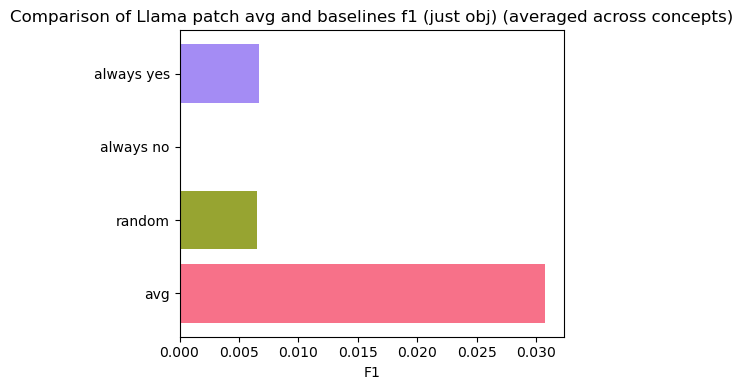

In [49]:
compare_to_baseline(metric_type='f1', 
                    primary_scheme='avg', 
                    dataset_name='Coco', 
                    model_name='Llama', 
                    sample_type='patch',
                    justobj=True,
                    plot_average=True)

## Compare Models

In [50]:
def compare_models(metric_type, primary_scheme, dataset_name, all_models, sample_type, justobj=False, 
                   baseline_type='random', plot_average=True, xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    metric_dfs = {}
    for model_name in all_models:
        if primary_scheme == 'avg':
            path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
        elif primary_scheme == 'linsep (no balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
        elif primary_scheme == 'linsep (overall balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
        elif primary_scheme == 'linsep (overall and negative balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv' 
            
        if sample_type == 'patch' and justobj:
            metric_path = f'{dir}/justobj_{path}'
        else:
            metric_path = f'{dir}/{path}'
            
        metric_dfs[model_name] = pd.read_csv(metric_path)
    
    for model_name in all_models:
        if sample_type == 'patch' and justobj:
            baseline_path = f'{dir}/{baseline_type}_justobj_{model_name}_{sample_type}_baseline.csv'
        else:
            baseline_path = f'{dir}/{baseline_type}_{model_name}_{sample_type}_baseline.csv'
        metric_dfs[f'{model_name} {" ".join(baseline_type.split("_"))}'] = pd.read_csv(baseline_path)
    
    
    title = f'Comparison of {primary_scheme} {sample_type} {metric_type} across models'
    if sample_type == 'patch' and justobj:
        title += ' (just obj)'
    if plot_average:
        plot_average_metrics(metric_dfs,
                         metric_type,
                         title = f'{title}\n (averaged across {dataset_name} concepts)',
                         xmin=xmin, xmax=xmax)
    else:
        plot_concept_metrics(metric_dfs,
                         metric_type,
                         title, xmin=xmin, xmax=xmax)

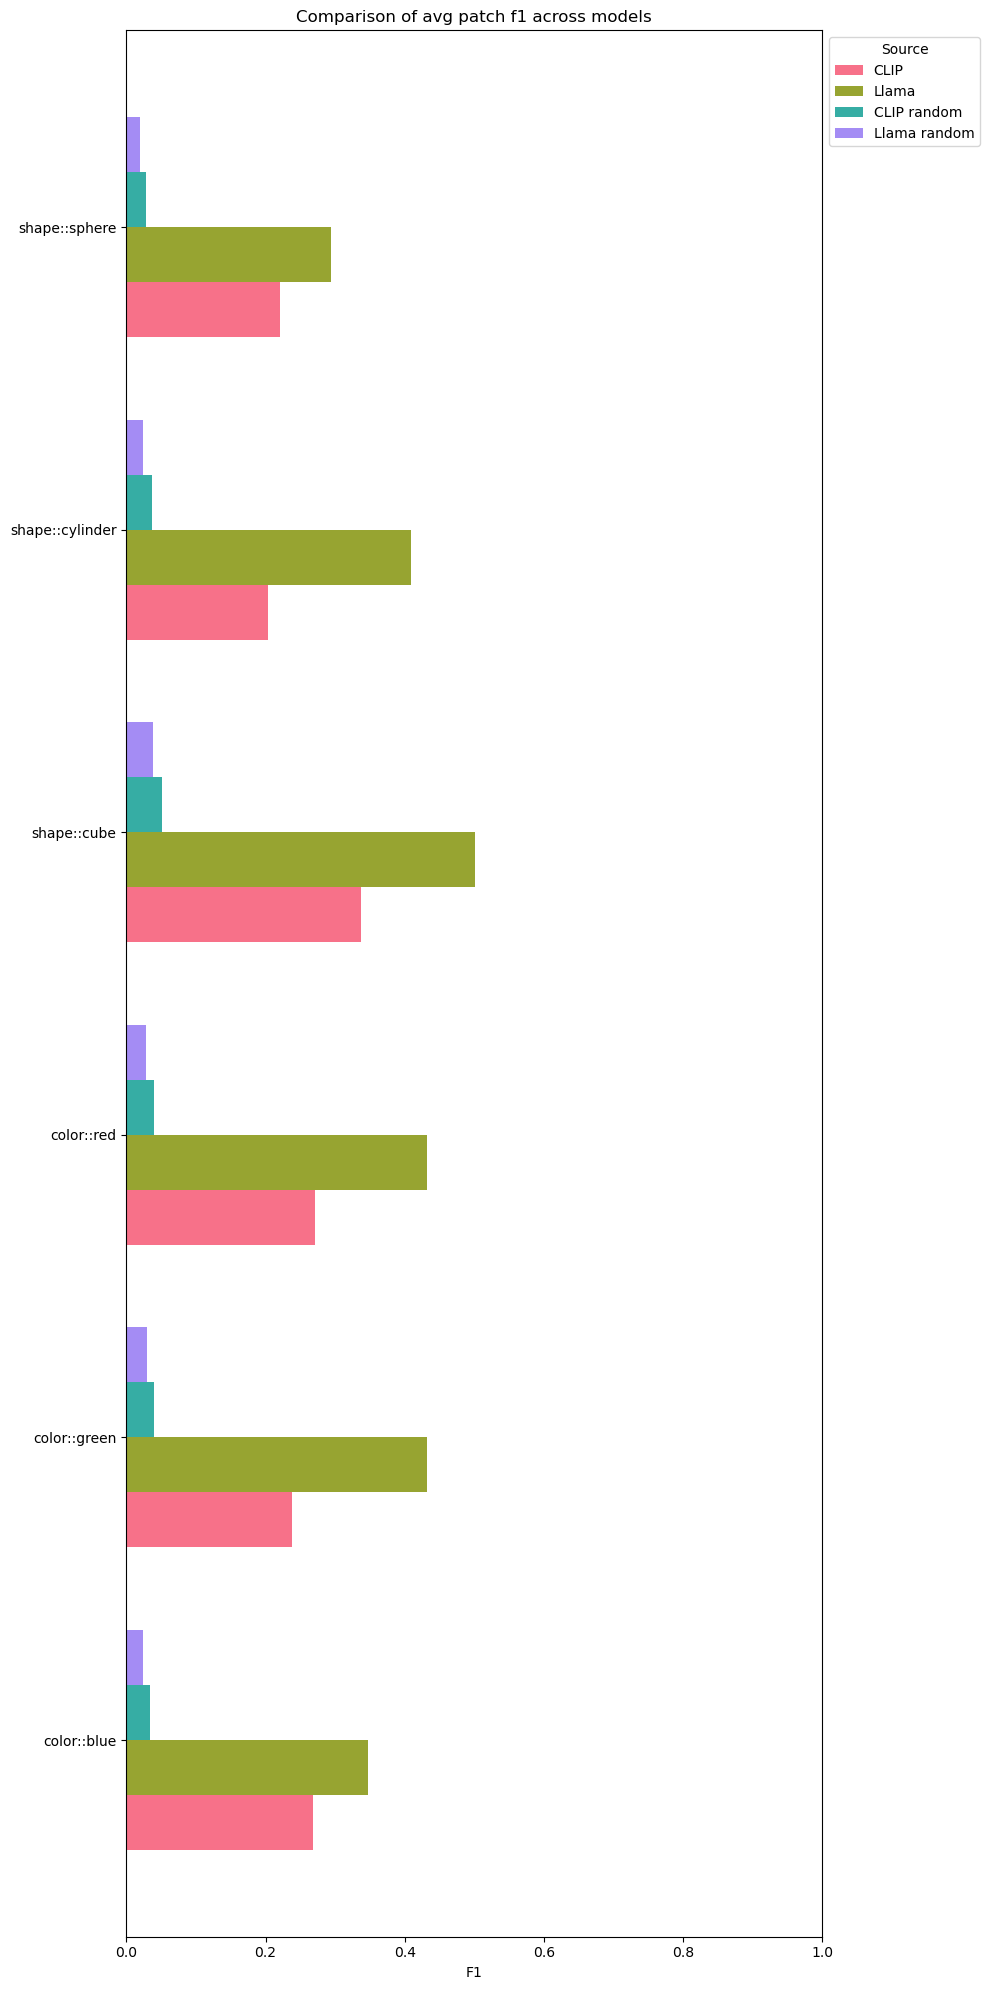

In [51]:
compare_models(metric_type='f1', 
               primary_scheme='avg', 
               dataset_name='CLEVR', 
               all_models=['CLIP', 'Llama'], 
               sample_type='patch', 
               baseline_type='random',
               xmin=0, 
               xmax=1,
               justobj=False,
               plot_average=False)

## Compare Model and Techniques

In [ ]:
def compare_model_performance_across_techniques(metric_type, concept_schemes, dataset_name, 
                                                    all_models, sample_type, curr_concepts=None, justobj=False, 
                                                   baseline_type='random', plot_average=True, 
                                                  xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    model_metric_dfs = {}
    
    #baselines
    baseline_dfs = {}
    for model_name in all_models:
        if sample_type == 'patch' and justobj:
            baseline_path = f'{dir}/{baseline_type}_justobj_{model_name}_{sample_type}_baseline.csv'
        else:
            baseline_path = f'{dir}/{baseline_type}_{model_name}_{sample_type}_baseline.csv'
        baseline_dfs[model_name] = pd.read_csv(baseline_path)
        
    for model_name in all_models: #different models
        scheme_metric_dfs = {}
        for concept_scheme in concept_schemes: #different schemes
            if concept_scheme == 'avg':
                path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
            elif concept_scheme == 'linsep (no balancing)':
                path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
            elif concept_scheme == 'linsep (overall balancing)':
                path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
            elif concept_scheme == 'linsep (overall and negative balancing)':
                path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv' 

            if sample_type == 'patch' and justobj:
                metric_path = f'{dir}/justobj_{path}'
            else:
                metric_path = f'{dir}/{path}'

            scheme_metric_dfs[concept_scheme] = pd.read_csv(metric_path)
        model_metric_dfs[model_name] = scheme_metric_dfs
    
    title = f'Avg {metric_type.upper()} for {sample_type.capitalize()} Methods on {dataset_name}'
    if sample_type == 'patch' and justobj:
        title += '\n(Just Obj)'
    
    if plot_average:
        plot_average_grouped_metrics(model_metric_dfs, baseline_dfs, metric_type, baseline_type, 
                                     title=title, xmin=xmin, xmax=xmax)
    else:
        plot_grouped_metrics(model_metric_dfs, baseline_dfs, metric_type, baseline_type,
                             curr_concepts, title=title, xmin=xmin, xmax=xmax)

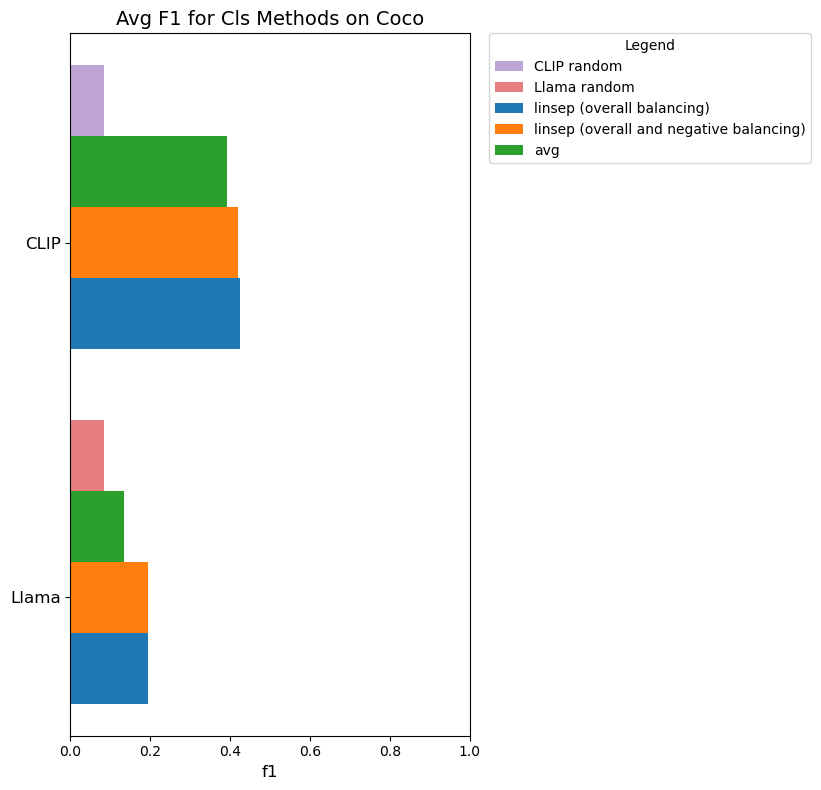

In [867]:
schemes = ['linsep (overall and negative balancing)', 'linsep (overall balancing)', 'avg']
curr_concepts = ['animal', 'person', 'vehicle', 'cow', 'bowl']
compare_model_performance_across_techniques(metric_type='f1', 
                                                concept_schemes=schemes,
                                                dataset_name='Coco', 
                                                all_models=['Llama', 'CLIP'], 
                                                sample_type='cls', 
                                                justobj=False, 
                                                baseline_type='random',
                                                curr_concepts=None,
                                                plot_average=True,
                                                xmin=0, xmax=1)

## Compare Concept Schemes

In [52]:
def compare_schemes(metric_type, concept_schemes, dataset_name, model_name, sample_type, justobj=False, 
                    baseline_type='random', plot_average=True, xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    metric_dfs = {}
    
    #different schemes
    for concept_scheme in concept_schemes:
        if concept_scheme == 'avg':
            path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
        elif concept_scheme == 'linsep (no balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
        elif concept_scheme == 'linsep (overall balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
        elif concept_scheme == 'linsep (overall and negative balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv' 
            
        if sample_type == 'patch' and justobj:
            metric_path = f'{dir}/justobj_{path}'
        else:
            metric_path = f'{dir}/{path}'
            
        metric_dfs[concept_scheme] = pd.read_csv(metric_path)
    
    #baseline
    if sample_type == 'patch' and justobj:
        metric_dfs[f'{" ".join(baseline_type.split("_"))}'] = pd.read_csv(f'{dir}/{baseline_type}_justobj_{model_name}_{sample_type}_baseline.csv')
    else:
        metric_dfs[f'{" ".join(baseline_type.split("_"))}'] = pd.read_csv(f'{dir}/{baseline_type}_{model_name}_{sample_type}_baseline.csv')
    
    
    title = f'{metric_type} across {model_name} {sample_type} concept schemes on {dataset_name}'
    if sample_type == 'patch' and justobj:
        title += '\n(just obj)'
    if plot_average:
        plot_average_metrics(metric_dfs,
                         metric_type,
                         title = f'{title}\n(averaged across concepts)',
                          xmin=xmin, xmax=xmax)
    else:
        plot_concept_metrics(metric_dfs,
                         metric_type,
                         title, xmin=xmin, xmax=xmax)

In [57]:
schemes = ['avg', 'linsep (overall balancing)', 'linsep (overall and negative balancing)']
compare_schemes(metric_type='f1', 
                concept_schemes=schemes,
                dataset_name='CLEVR', 
                model_name='CLEVR', 
                sample_type='patch', 
                baseline_type='random', 
                xmin=0, 
                xmax=0.35,
                justobj=False,
                plot_average=False)

FileNotFoundError: [Errno 2] No such file or directory: 'Quant_Results/CLEVR/CLEVR_avg_patch_embeddings_percentthrumodel_100.csv'

# Detection Plots

In [31]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_activation_percentages(dataset_name, split, model_name, sample_types, weighted_avg=False):
    """
    Plots activation percentages with in-sample percentile on the x-axis and percentage on the y-axis.

    Args:
        dataset_name (str): Name of the dataset.
        split (str): Either "train" or "test".
        model_name (str): Model name
        sample_types (list): List of sample types to include.
    
    Returns:
        None (displays the plot).
    """
    plt.figure(figsize=(8, 6))
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
    
    con_labels = {}
    for sample_type in sample_types:
        con_labels[f'{sample_type}: avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'{sample_type}: linsep (overall bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100' 
        con_labels[f'{sample_type}: linsep (overall + neg bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100'

    line_styles = {'In-Concept': '-', 'Out-Concept': '--'}  # Solid for in, dotted for out
    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

    if model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt')
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt')
    
    #add baselines (HARDCODED)
    if dataset_name == 'Coco':
        tpr = 0.9191
        fpr = 0.1100
    elif dataset_name == 'CLEVR':
        tpr = 1.0000
        fpr = 0.0012
        
    baseline_tprs = [tpr * 100 for _ in range(len(percentiles))]
    baseline_fprs = [fpr * 100 for _ in range(len(percentiles))]
    plt.plot(percentiles, baseline_tprs, color='gray', linestyle=line_styles['In-Concept'], marker='o', label='Prompt-Concept Baseline')
    plt.plot(percentiles, baseline_fprs, color='gray', linestyle=line_styles['Out-Concept'], marker='o')
    
    for i, (name, con_label) in enumerate(con_labels.items()):
        in_percentages, out_percentages = [], []
        for percentile in percentiles:
            in_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_inconcept_{con_label}.pt'
            out_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_outconcept_{con_label}.pt'
            in_pct_data = torch.load(in_file_path)
            out_pct_data = torch.load(out_file_path)
            in_pct_data = {k:v for k,v in in_pct_data.items() if k in gt_samples_per_concept.keys()}
            out_pct_data = {k:v for k,v in out_pct_data.items() if k in gt_samples_per_concept.keys()}
            
            if weighted_avg:
                total_in_count = sum(len(gt_samples_per_concept[concept]) for concept in in_pct_data.keys())
                total_out_count = sum(len(gt_samples_per_concept[concept]) for concept in out_pct_data.keys())
                avg_in_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in in_pct_data.items()) / total_in_count
                avg_out_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in out_pct_data.items()) /  total_out_count
            else:
                avg_in_percent = sum(in_pct_data.values()) / len(in_pct_data)
                avg_out_percent = sum(out_pct_data.values()) / len(out_pct_data)
            in_percentages.append(avg_in_percent)
            out_percentages.append(avg_out_percent)

        plt.plot(percentiles, in_percentages, linestyle=line_styles['In-Concept'], color=colors[i], marker='o', label=name)
        plt.plot(percentiles, out_percentages, linestyle=line_styles['Out-Concept'], color=colors[i], marker='s')
             
    # Custom legend
    legend_elements = []
    for i, name in enumerate(con_labels.keys()):
        legend_elements.append(plt.Line2D([0], [0], color=colors[i], lw=2, label=name))

    #Baselines 
    legend_elements.append(plt.Line2D([0], [0], color='gray', lw=2, label='Prompt-Concept Baseline'))
             
    # Line style legend for in/out concept
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', lw=2, label='In-Concept'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', lw=2, label='Out-Concept'))

    plt.ylim(-5, 105)
    plt.xlabel("Chosen In-Sample Percentile")
    plt.ylabel("Image Activation Percentage")
    plt.title(f"Image Activation Percentages for {model_name} on {dataset_name} ({split.capitalize()} split)")

    # Move the legend outside the plot
    plt.legend(handles=legend_elements, title="Concept Discovery Techniques", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.grid(True)
    plt.show()
    
    
def plot_activation_percentages_diffs(dataset_name, split, model_name, sample_types, weighted_avg=False):
    """
    Plots the difference between activation percentages.

    Args:
        dataset_name (str): Name of the dataset.
        split (str): Either "train" or "test".
        model_name (str): Model name
        sample_types (list): List of sample types to include.
    
    Returns:
        None (displays the plot).
    """
    plt.figure(figsize=(8, 6))
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
    
    con_labels = {}
    for sample_type in sample_types:
        con_labels[f'{sample_type}: avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'{sample_type}: linsep (overall bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100' 
        con_labels[f'{sample_type}: linsep (overall + neg bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100'

    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

    if model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt')
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt')
    
    #add baselines (HARDCODED)
    if dataset_name == 'Coco':
        tpr = 0.9191
        fpr = 0.1100
    elif dataset_name == 'CLEVR':
        tpr = 1.0000
        fpr = 0.0012
        
    baseline_vals = [(tpr * 100)- (fpr*100) for _ in range(len(percentiles))]
    plt.plot(percentiles, baseline_vals, color='gray', marker='o', label='Prompt-Concept Baseline')
    
    for i, (name, con_label) in enumerate(con_labels.items()):
        percent_diffs = []
        for percentile in percentiles:
            in_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_inconcept_{con_label}.pt'
            out_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_outconcept_{con_label}.pt'
            in_pct_data = torch.load(in_file_path)
            out_pct_data = torch.load(out_file_path)
            in_pct_data = {k:v for k,v in in_pct_data.items() if k in gt_samples_per_concept.keys()}
            out_pct_data = {k:v for k,v in out_pct_data.items() if k in gt_samples_per_concept.keys()}
            if weighted_avg:
                total_in_count = sum(len(gt_samples_per_concept[concept]) for concept in in_pct_data.keys())
                total_out_count = sum(len(gt_samples_per_concept[concept]) for concept in out_pct_data.keys())
                avg_in_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in in_pct_data.items()) / total_in_count
                avg_out_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in out_pct_data.items()) /  total_out_count
            else:
                avg_in_percent = sum(in_pct_data.values()) / len(in_pct_data)
                avg_out_percent = sum(out_pct_data.values()) / len(out_pct_data)
            percent_diffs.append(avg_in_percent - avg_out_percent)

        plt.plot(percentiles, percent_diffs, color=colors[i], marker='o', label=name)
        
        
    # Custom legend
    legend_elements = []
    for i, name in enumerate(con_labels.keys()):
        legend_elements.append(plt.Line2D([0], [0], color=colors[i], lw=2, label=name))
    #Baselines 
    legend_elements.append(plt.Line2D([0], [0], color='gray', lw=2, label='Prompt-Concept Baseline'))
        
    plt.ylim(-5, 105)
    plt.xlabel("Chosen In-Sample Percentile")
    plt.ylabel("In-concept Act Img % - Out-Concept Img Act %")
    plt.title(f"Image Activation Percentage Differences for {model_name} on {dataset_name} ({split.capitalize()} split)")

    # Move the legend outside the plot
    plt.legend(handles=legend_elements, title="Concept Discovery Techniques", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.grid(True)
    plt.show()

    
def get_prompt_scores(dataset_name, metric):
    if dataset_name == 'Coco':
        # first element prompt: 'output all concepts present in the image'
        # second element prompt: 'Does the image contain X?'
        concept_f1s = {
            'bed': (0.5490196078431373, 0.29743589743589743),
            'surfboard': (0.5, 0.8666666666666666),
            'bicycle': (0.5263157894736843, 0.6236559139784946),
            'spoon': (0.43609022556390975, 0.45283018867924535),
            'pizza': (0.8, 0.8450704225352113),
            'fork': (0.3544303797468354, 0.3851851851851852),
            'train': (0.813953488372093, 0.6728971962616822),
            'motorcycle': (0.6153846153846153, 0.7246376811594204),
            'tennis racket': (0.9350649350649352, 0.9333333333333333),
            'sports ball': (0.4807692307692308, 0.6206896551724138),
            'potted plant': (0.16445623342175064, 0.24267782426778245),
            'umbrella': (0.7536231884057972, 0.5934065934065935),
            'dog': (0.5714285714285715, 0.5904761904761905),
            'knife': (0.44736842105263164, 0.5384615384615384),
            'laptop': (0.3636363636363636, 0.5979381443298969),
            'cat': (0.7951807228915663, 0.7816091954022989),
            'sink': (0.6417910447761194, 0.5540540540540541),
            'bus': (0.7961165048543688, 0.5443037974683544),
            'traffic light': (0.7474747474747475, 0.7659574468085106),
            'couch': (0.4429530201342282, 0.5000000000000001),
            'clock': (0.38918918918918916, 0.4320987654320988),
            'tv': (0.3135593220338983, 0.4714285714285714),
            'cell phone': (0.29773462783171517, 0.619718309859155),
            'backpack': (0.5606060606060606, 0.5483870967741935),
            'book': (0.4696969696969696, 0.2907488986784141),
            'bench': (0.37010676156583633, 0.22698072805139186),
            'truck': (0.5777777777777778, 0.4277456647398844),
            'handbag': (0.43824701195219123, 0.5213270142180095),
            'bowl': (0.37249283667621774, 0.33780160857908853),
            'appliance': (0.22333333333333333, 0.38040345821325644),
            'bottle': (0.4545454545454545, 0.5118110236220472),
            'cup': (0.44728434504792336, 0.4930555555555556),
            'dining table': (0.7400881057268722, 0.6953405017921146),
            'car': (0.7850467289719627, 0.6149253731343284),
            'outdoor': (0.35658914728682173, 0.3562340966921119),
            'chair': (0.36645962732919257, 0.5248868778280542),
            'electronic': (0.24629418472063852, 0.4855769230769231),
            'indoor': (0.3400936037441497, 0.30559345156889495),
            'food': (0.7901907356948228, 0.8011204481792717),
            'accessory': (0.2526115859449193, 0.2682403433476395),
            'kitchen': (0.6453333333333334, 0.628415300546448),
            'sports': (0.8293838862559242, 0.8661417322834646),
            'animal': (0.6633825944170771, 0.8056112224448897),
            'vehicle': (0.7845117845117846, 0.8528864059590316),
            'furniture': (0.5175438596491228, 0.6750788643533122),
            'person': (0.9447513812154695, 0.9281961471103327)
        }

        tpr = 0.9191
        fpr = 0.1100
        
    elif dataset_name == 'CLEVR':
        concept_f1s = {
            'color::blue': (1.0, 1.0), 'color::green': (1.0, 1.0), 'color::red': (1.0, 1.0),
            'shape::cube': (1.0, 1.0), 'shape::cylinder': (0.9917355371900827, 0.9917355371900827), 'shape::sphere': (1.0, 1.0)
        }
        tpr = 1.0000
        fpr = 0.0012
        
    if metric == 'f1':
        return concept_f1s
    elif metric == 'tpr':
        return tpr
    elif metric == 'fpr':
        return fpr



def plot_detection_scores(dataset_name, split, model_name, sample_types, metric='f1', weighted_avg=True):
    """
    Plots detection scores (F1, TPR, FPR) across different percentiles for different concept discovery methods.
    """
    plt.figure(figsize=(10, 7))
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
    
    con_labels = {}
    for sample_type in sample_types:
        if sample_type == 'patch':
            n_clusters = 1000
        elif sample_type == 'cls':
            n_clusters = 50
        con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        
        
        
    colors = ['red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'pink']

    if model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt')
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt')

    # === Plot weighted prompt detection ===
    prompt_scores = get_prompt_scores(dataset_name, metric)
    if metric == 'f1':
        filtered_prompt_scores = {k: v for k, v in prompt_scores.items() if k in gt_samples_per_concept.keys()}
        if weighted_avg:
            total_samples = sum(len(gt_samples_per_concept[k]) for k in filtered_prompt_scores.keys())

            weighted_sum1 = sum(filtered_prompt_scores[k][0] * len(gt_samples_per_concept[k]) for k in filtered_prompt_scores.keys())
            weighted_sum2 = sum(filtered_prompt_scores[k][1] * len(gt_samples_per_concept[k]) for k in filtered_prompt_scores.keys())

            avg_prompt1 = weighted_sum1 / total_samples
            avg_prompt2 = weighted_sum2 / total_samples
        else:
            avg_prompt1 = np.mean([score_pair[0] for score_pair in filtered_prompt_scores.values()])
            avg_prompt2 = np.mean([score_pair[1] for score_pair in filtered_prompt_scores.values()])
    else:
        avg_prompt1 = prompt_scores  # tpr or fpr is a single number
        avg_prompt2 = prompt_scores

    print(avg_prompt1)
    print(avg_prompt2)
    plt.axhline(avg_prompt1, color='brown', linestyle='--', linewidth=2, label=f"Prompt1 (Output All Present Concepts)")
    plt.axhline(avg_prompt2, color='gray', linestyle='--', linewidth=2, label=f"Prompt2 (Is X Concept Present)")

    # === Plot each discovery technique ===
    for i, (name, con_label) in enumerate(con_labels.items()):
        scores = []

        for percentile in percentiles:
            detection_metrics = torch.load(f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt')
            
            # Only keep concepts that are present in GT
            detection_metrics = detection_metrics[detection_metrics['concept'].isin(gt_samples_per_concept.keys())]

            if weighted_avg:
                total_samples = sum(len(gt_samples_per_concept[concept]) for concept in detection_metrics['concept'])
                weighted_sum = 0

                for idx, row in detection_metrics.iterrows():
                    n_samples = len(gt_samples_per_concept[row['concept']])
                    if metric == 'f1':
                        weighted_sum += row['f1'] * n_samples
                    elif metric == 'tpr':
                        weighted_sum += row['tpr'] * n_samples
                    elif metric == 'fpr':
                        weighted_sum += row['fpr'] * n_samples
                    else:
                        raise ValueError(f"Unsupported metric: {metric}")

                score = weighted_sum / total_samples if total_samples > 0 else 0
            else:
                if metric == 'f1':
                    score = detection_metrics['f1'].mean()
                elif metric == 'tpr':
                    score = detection_metrics['tpr'].mean()
                elif metric == 'fpr':
                    score = detection_metrics['fpr'].mean()
                else:
                    raise ValueError(f"Unsupported metric: {metric}")

            scores.append(score)

        plt.plot(percentiles, scores, color=colors[i], marker='o', label=name)

    # ====== Clean x-axis ======
    plt.xlabel("Chosen In-Sample Percentile")
    plt.ylabel(f"{metric.upper()} Score")
    plt.ylim(0, 1.1)
    plt.xlim(0, 1.05)

    plt.xticks(np.linspace(0, 1.0, 11), [f"{int(x*100)}%" for x in np.linspace(0, 1.0, 11)])
    plt.title(f"{metric.upper()} Detection Scores Across Percentiles for {model_name} on {dataset_name} ({split.capitalize()} split)")
    plt.legend(title="Concept Discovery Techniques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    
    
def summarize_best_detection_scores(dataset_name, split, model_name, sample_types, metric='f1', weighted_avg=True):
    """
    Returns a DataFrame summarizing the best detection score (and the percentile it occurs at)
    for each concept discovery method.
    """
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]

    # === Construct concept label mappings
    con_labels = {}
    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == 'patch' else 50
        con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'

    # === Load ground-truth labels
    if model_name == 'CLIP':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt'
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt'
    gt_samples_per_concept = torch.load(gt_path)

    # === Compute best scores
    results = []

    for name, con_label in con_labels.items():
        best_score = -1
        best_percentile = None

        for percentile in percentiles:
            detection_metrics = torch.load(f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt', weight_only=False)
            detection_metrics = detection_metrics[detection_metrics['concept'].isin(gt_samples_per_concept.keys())]

            if weighted_avg:
                total_samples = sum(len(gt_samples_per_concept[c]) for c in detection_metrics['concept'])
                weighted_sum = 0

                for _, row in detection_metrics.iterrows():
                    n_samples = len(gt_samples_per_concept[row['concept']])
                    weighted_sum += row[metric] * n_samples

                score = weighted_sum / total_samples if total_samples > 0 else 0
            else:
                score = detection_metrics[metric].mean()

            if score > best_score:
                best_score = score
                best_percentile = percentile

        results.append({
            'Method': name,
            f'Best {metric.upper()}': round(best_score, 4),
            'Percentile': best_percentile
        })

    return pd.DataFrame(results)

from collections import defaultdict
def summarize_best_detection_scores_per_concept(dataset_name, split, model_name, sample_types, metric='f1'):
    """
    Returns a DataFrame showing, for each concept and discovery method,
    the best detection score and the corresponding percentile.

    Columns: [concept, method, best_<metric>, percentile]
    """
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]

    # === Build concept discovery labels
    con_labels = {}
    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == 'patch' else 50
        con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'

    # === Load GT concepts
    if model_name == 'CLIP':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt'
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt'
    gt_concepts = torch.load(gt_path)

    results = []

    for method_name, con_label in con_labels.items():
        per_concept_best = defaultdict(lambda: (-1, None))  # concept -> (best_score, best_percentile)

        for percentile in percentiles:
            try:
                df = torch.load(f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt')
            except FileNotFoundError:
                continue

            df = df[df['concept'].isin(gt_concepts.keys())]

            for _, row in df.iterrows():
                c = row['concept']
                score = row[metric]

                if score > per_concept_best[c][0]:
                    per_concept_best[c] = (score, percentile)

        for concept, (score, percentile) in per_concept_best.items():
            results.append({
                'concept': concept,
                'method': method_name,
                f'best_{metric}': round(score, 4),
                'percentile': percentile
            })

    return pd.DataFrame(results)

## In vs Out-Concept Activation Percentages

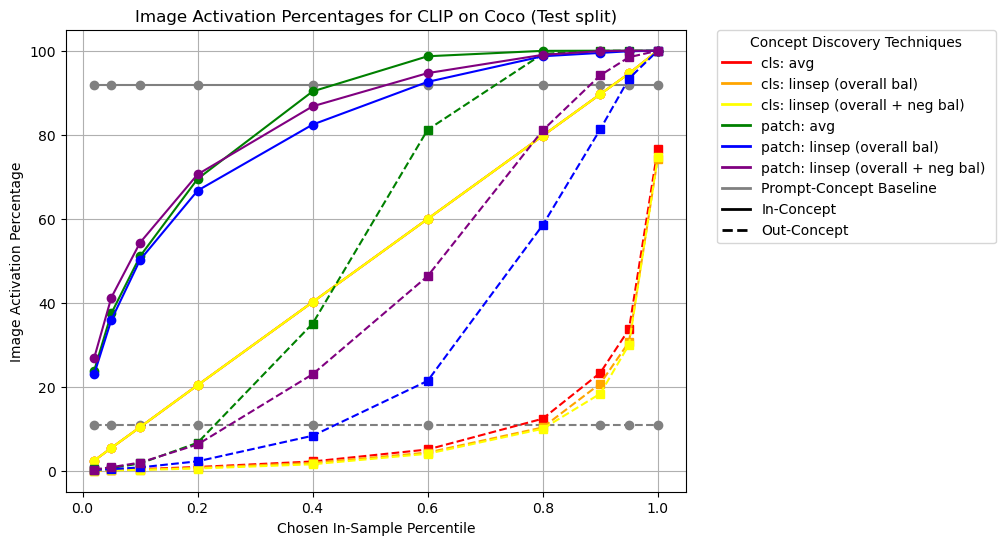

In [6]:
# Example usage
plot_activation_percentages(dataset_name='Coco',
                            split='test',
                            model_name = 'CLIP',
                            sample_types = ['cls', 'patch'],
                            weighted_avg=True)

## Diff Between In-Sample/Out of Sample Activation Percentages 

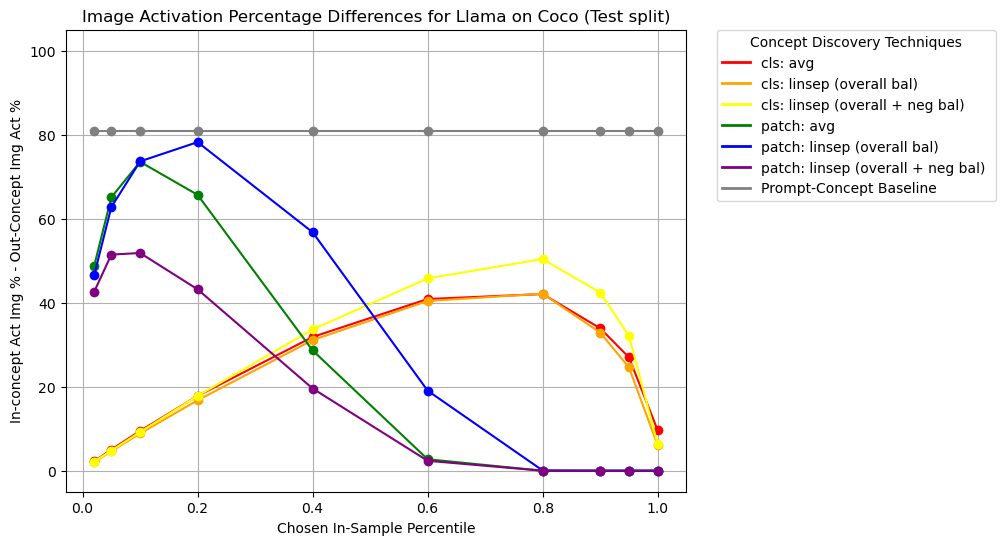

In [55]:
plot_activation_percentages_diffs(dataset_name='Coco',
                            split='test',
                            model_name = 'Llama',
                            sample_types = ['cls', 'patch'],
                            weighted_avg=True)

## Metrics for Detection

0.6233691895282262
0.6493223007155853


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pandas.core.frame.DataFrame was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pandas.core.frame.DataFrame])` or the `torch.serialization.safe_globals([pandas.core.frame.DataFrame])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more a

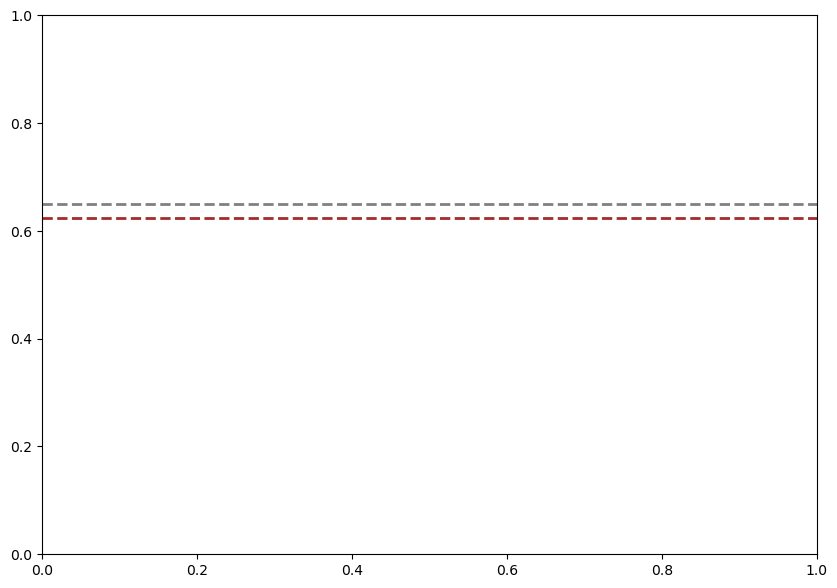

In [32]:
plot_detection_scores(dataset_name='Coco',
                split='test',
                model_name = 'Llama',
                sample_types = ['patch', 'cls'],
                metric='f1',
                weighted_avg=True)

In [26]:
summarize_best_detection_scores(dataset_name='Coco',
                                     split='test', 
                                     model_name='Llama', 
                                     sample_types=['patch', 'cls'],
                                     metric='f1', 
                                     weighted_avg=True)

,Method,Best F1,Percentile
0,labeled patch avg,0.7016,0.10
1,labeled patch linsep,0.7520,0.10
2,unsupervised patch kmeans,0.6796,0.05
3,unsupervised patch linsep kmeans,0.6539,0.02
4,labeled cls avg,0.4627,0.60
5,labeled cls linsep,0.4892,0.60
6,unsupervised cls kmeans,0.3626,0.60
7,unsupervised cls linsep kmeans,0.3574,0.80


In [27]:
emeds = torch.load('Embeddings/IMDB/raw_batches/raw_batch_0.pt')
print(emeds.shape)

torch.Size([3300, 4096])


In [19]:
summarize_best_detection_scores_per_concept(dataset_name = 'Coco', 
                                            split='test', 
                                            model_name = 'CLIP', 
                                            sample_types = ['patch', 'cls'], 
                                            metric='f1')

,concept,method,best_f1,percentile
0,accessory,labeled patch avg,0.5979,0.2
1,animal,labeled patch avg,0.7278,0.2
2,appliance,labeled patch avg,0.7730,0.4
3,bench,labeled patch avg,0.6847,0.2
4,book,labeled patch avg,0.4615,0.1
...,...,...,...,...
227,train,unsupervised cls linsep kmeans,0.8788,0.8
228,truck,unsupervised cls linsep kmeans,0.3085,0.6
229,tv,unsupervised cls linsep kmeans,0.4143,0.8
230,umbrella,unsupervised cls linsep kmeans,0.1481,0.2


# Compare Best Performing Detect/Invert Combo Across Techniques

In [22]:
import pandas as pd
import math

def compare_best_schemes(metric_type, concept_schemes, dataset_name, model_name, detect_percents, invert_percents,
                         justobj=False, superdetector_inversion=False, xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    best_metric_dfs = {}
    
    for concept_scheme in concept_schemes:
        best_avg_metric = -float('inf')
        best_df = None
        best_detect = None
        best_invert = None
        
        for detect_percentile in detect_percents:
            for invert_percentile in invert_percents:
                if invert_percentile < detect_percentile:
                    continue
                
                path = f'detectfirst_{detect_percentile*100}_per_{invert_percentile*100}'
                if superdetector_inversion:
                    path += '_superpatch_avg_inv'
                path += f'_{model_name}'
                if concept_scheme == 'avg':
                    path += '_avg_patch_embeddings_percentthrumodel_100.csv'
                elif concept_scheme == 'linsep':
                    path += '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans':
                    path += f'_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans linsep':
                    path += f'_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100.csv'
                else:
                    raise ValueError(f"Unrecognized concept scheme: {concept_scheme}")

                if justobj:
                    metric_path = f'{dir}/justobj_{path}'
                else:
                    metric_path = f'{dir}/{path}'
                
                try:
                    df = pd.read_csv(metric_path)
                except FileNotFoundError:
                    print(f"Warning: File not found {metric_path}, skipping.")
                    continue
                
                avg_metric = df[metric_type].mean()  # Average across concepts
                
                if avg_metric > best_avg_metric:
                    best_avg_metric = avg_metric
                    best_df = df
                    best_detect = detect_percentile
                    best_invert = invert_percentile
                    
        if best_df is not None:
            best_metric_dfs[f"{concept_scheme}\n(detect={best_detect}, invert={best_invert})"] = best_df
        else:
            print(f"No valid metrics found for {concept_scheme}.")

    # Now plot the best metrics
    title = f"Best {metric_type.capitalize()} for {model_name} Patch Schemes on {dataset_name}"
    if superdetector_inversion:
        title += "\n(Local Superdetector Inversion)"
    plot_average_metrics(best_metric_dfs, metric_type, 
                         title=title, 
                         xmin=xmin, xmax=xmax)
    
    
def compare_best_schemes_per_concept(metric_type, concept_schemes, dataset_name, model_name,
                                     detect_percents, invert_percents, justobj=False,
                                     superdetector_inversion=False, concepts_to_plot=None,
                                     xmin=None, xmax=None, n_cols=3):
    """
    For each concept separately, plots the best metric achieved by each scheme using subplots (3 per row).

    Args:
        metric_type (str): Metric to plot ('f1', 'accuracy', etc.)
        concept_schemes (list): List of concept schemes (e.g., 'avg', 'linsep - overall balancing', etc.)
        dataset_name (str): Dataset name.
        model_name (str): Model name.
        detect_percents (list): Detection percentiles.
        invert_percents (list): Inversion percentiles.
        justobj (bool): Whether to use object-only patches.
        superdetector_inversion (bool): Whether to use superdetector inversion paths.
        concepts_to_plot (list): List of concepts to plot (default = all concepts).
        xmin (float, optional): Min x-axis limit.
        xmax (float, optional): Max x-axis limit.
        n_cols (int): Number of subplots per row (default=3)
    """

    base_dir = f'Quant_Results/{dataset_name}'
    
    concept_to_best_metrics = {}

    for concept_scheme in concept_schemes:
        best_metrics_per_concept = {}

        for detect_percentile in detect_percents:
            for invert_percentile in invert_percents:
                if invert_percentile < detect_percentile:
                    continue

                path = f'detectfirst_{detect_percentile*100}_per_{invert_percentile*100}'
                if superdetector_inversion:
                    path += '_superpatch_avg_inv'
                path += f'_{model_name}'

                if concept_scheme == 'avg':
                    path += '_avg_patch_embeddings_percentthrumodel_100.csv'
                elif concept_scheme == 'linsep':
                    path += '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans':
                    path += f'_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans linsep':
                    path += f'_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100.csv'
                else:
                    raise ValueError(f"Unrecognized concept scheme: {concept_scheme}")

                metric_path = f'{base_dir}/justobj_{path}' if justobj else f'{base_dir}/{path}'

                try:
                    df = pd.read_csv(metric_path)
                except FileNotFoundError:
                    print(f"Warning: File not found {metric_path}, skipping.")
                    continue

                for idx, row in df.iterrows():
                    concept = row['concept']
                    score = row[metric_type]

                    if concept not in best_metrics_per_concept or score > best_metrics_per_concept[concept][0]:
                        best_metrics_per_concept[concept] = (score, detect_percentile, invert_percentile)

        concept_to_best_metrics[concept_scheme] = best_metrics_per_concept

    # Now prepare plotting
    all_concepts = set()
    for scheme_best in concept_to_best_metrics.values():
        all_concepts.update(scheme_best.keys())

    if concepts_to_plot is None:
        concepts_to_plot = sorted(list(all_concepts))

    n_concepts = len(concepts_to_plot)
    n_rows = math.ceil(n_concepts / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for idx, concept in enumerate(concepts_to_plot):
        ax = axes[idx]
        
        scores = []
        labels = []

        for concept_scheme in concept_schemes:
            if concept in concept_to_best_metrics[concept_scheme]:
                score, detect, invert = concept_to_best_metrics[concept_scheme][concept]
                scores.append(score)
                labels.append(f"{concept_scheme}\n(detect={detect}, invert={invert})")
            else:
                scores.append(0.0)
                labels.append(f"{concept_scheme}\n(not found)")

        colors = sns.color_palette("husl", len(labels))
        bars = ax.barh(labels, scores, color=colors)

        # Annotate
        for bar, value in zip(bars, scores):
            ax.text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                va='center',
                ha='left',
                fontsize=9,
                fontweight='bold'
            )

        ax.set_title(f"{concept}", fontsize=11)
        ax.set_xlim(left=xmin if xmin is not None else 0, right=xmax if xmax is not None else 1)
        ax.set_xlabel(metric_type.capitalize())
        ax.grid(axis='x', linestyle='--', linewidth=0.5)

    # Hide unused subplots
    for i in range(n_concepts, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f"Best {metric_type.capitalize()} per Concept ({model_name} on {dataset_name})",
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    

def summarize_best_inversion_metrics(metric_type, concept_schemes, dataset_name, model_name, detect_percents, invert_percents,
                                     justobj=False, superdetector_inversion=False):
    """
    Summarizes the best average metric (e.g., F1, TPR) for each concept scheme across detect/invert percentiles.

    Returns:
        pd.DataFrame: One row per concept scheme with best score and corresponding detect/invert thresholds.
    """
    base_dir = f'Quant_Results/{dataset_name}'
    summary_rows = []

    for concept_scheme in concept_schemes:
        best_avg_metric = -float('inf')
        best_detect = None
        best_invert = None
        best_file = None

        for detect_percentile in detect_percents:
            for invert_percentile in invert_percents:
                if invert_percentile < detect_percentile:
                    continue

                path = f'detectfirst_{int(detect_percentile*100)}_per_{int(invert_percentile*100)}'
                if superdetector_inversion:
                    path += '_superpatch_avg_inv'
                path += f'_{model_name}'

                if concept_scheme == 'avg':
                    path += '_avg_patch_embeddings_percentthrumodel_100.csv'
                elif concept_scheme == 'linsep':
                    path += '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans':
                    path += f'_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans linsep':
                    path += f'_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100.csv'
                else:
                    raise ValueError(f"Unrecognized concept scheme: {concept_scheme}")

                metric_path = os.path.join(base_dir, f'justobj_{path}' if justobj else path)

                if not os.path.exists(metric_path):
                    continue

                df = pd.read_csv(metric_path)
                avg_metric = df[metric_type].mean()

                if avg_metric > best_avg_metric:
                    best_avg_metric = avg_metric
                    best_detect = detect_percentile
                    best_invert = invert_percentile
                    best_file = path
                    
        if superdetector_inversion:
            scheme_name = f'{concept_scheme} superdetector cossim'
        else:
            scheme_name = f'{concept_scheme} concept cossim'
        summary_rows.append({
            'Scheme': concept_scheme,
            f'Best Avg {metric_type.upper()}': round(best_avg_metric, 4) if best_avg_metric > -1 else None,
            'Detect %': best_detect,
            'Invert %': best_invert,
            'File': best_file
        })

    return pd.DataFrame(summary_rows)

In [21]:
schemes = ['avg', 'linsep', 'unsupervised kmeans', 'unsupervised kmeans linsep']
percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.95, 1.0]
compare_best_schemes(metric_type='f1', 
                     concept_schemes=schemes, 
                     dataset_name='CLEVR', 
                     model_name='CLIP', 
                     detect_percents=percentiles, 
                     invert_percents=percentiles,
                     superdetector_inversion=False,
                     justobj=False, 
                     xmin=0.0, 
                     xmax=1.0)

No valid metrics found for unsupervised kmeans linsep.


NameError: name 'plot_average_metrics' is not defined

In [13]:
summarize_best_inversion_metrics(metric_type='f1', 
                                 concept_schemes=['avg', 'linsep', 'unsupervised kmeans', 'unsupervised kmeans linsep'], 
                                 dataset_name='CLEVR', 
                                 model_name='CLIP', 
                                 detect_percents=[0.02, 0.05, 0.1], 
                                 invert_percents=[0.2, 0.4, 0.6, 0.8, 1.0],
                                 justobj=False, 
                                 superdetector_inversion=False)

,Scheme,Best Avg F1,Detect %,Invert %,File
0,avg,None,None,None,None
1,linsep,None,None,None,None
2,unsupervised kmeans,None,None,None,None
3,unsupervised kmeans linsep,None,None,None,None


## Per Concept

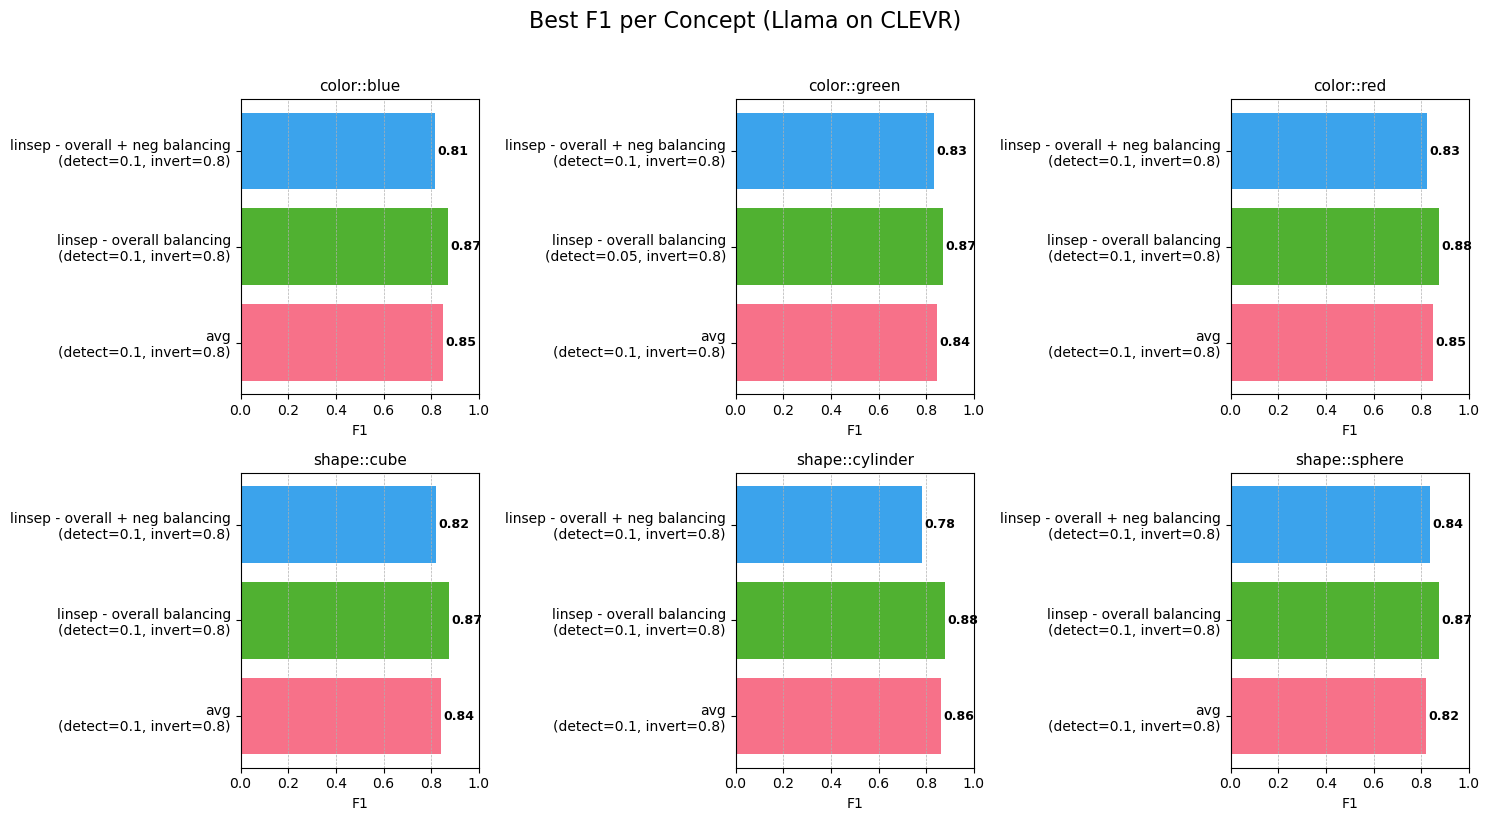

In [43]:
compare_best_schemes_per_concept(
    metric_type='f1',
    concept_schemes=['avg', 'linsep', 'unsupervised kmeans', 'unsupervised kmeans linsep'],
    dataset_name='CLEVR',
    model_name='Llama',
    detect_percents=[0.02, 0.05, 0.1],
    invert_percents=[0.2, 0.4, 0.6, 0.8, 1.0],
    justobj=False,
    superdetector_inversion=False,
    xmin=0.0,
    xmax=1.0
)